#### 1. Загрузка данных и моделей

In [35]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

train_path = DATA_DIR / "features_train_5class.csv"
test_path = DATA_DIR / "features_test_5class.csv"

lr_model_path = MODELS_DIR / "lr_5class_model.pkl"
mlp_model_path = MODELS_DIR / "mlp_model.pkl"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

lr_model = joblib.load(lr_model_path)
mlp_model = joblib.load(mlp_model_path)

# Старое имя оставлено, чтобы следующие ячейки ноутбука работали без переписывания.
logreg_model = lr_model

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("Логистическая модель:", type(lr_model))
print("MLP модель:", type(mlp_model))

print("Классы LR модели:", lr_model.classes_)
print("Классы MLP модели:", mlp_model.classes_)


Train: (28234, 25)
Test: (7403, 25)
Логистическая модель: <class 'sklearn.multiclass.OneVsRestClassifier'>
MLP модель: <class 'sklearn.neural_network._multilayer_perceptron.MLPClassifier'>
Классы LR модели: [0 1 2 3 4]
Классы MLP модели: [0 1 2 3 4]


#### 2. Подготовка признаков и стандартизация

In [36]:
X_train = train_df.drop(columns=["Activity"])
y_train = train_df["Activity"]

X_test = test_df.drop(columns=["Activity"])
y_test = test_df["Activity"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Псевдонимы для старых ячеек: теперь и LR, и MLP работают с одними 5-классовыми данными.
X_train_logreg = X_train
X_test_logreg = X_test
y_train_logreg = y_train
y_test_logreg = y_test
X_train_logreg_scaled = X_train_scaled
X_test_logreg_scaled = X_test_scaled

X_train_mlp = X_train
X_test_mlp = X_test
y_train_mlp = y_train
y_test_mlp = y_test
X_train_mlp_scaled = X_train_scaled
X_test_mlp_scaled = X_test_scaled

print("Размер X_train:", X_train.shape)
print("Размер y_train:", y_train.shape)

print("Размер X_test:", X_test.shape)
print("Размер y_test:", y_test.shape)

print("Классы в train:", sorted(y_train.unique()))
print("Классы в test:", sorted(y_test.unique()))


Размер X_train: (28234, 24)
Размер y_train: (28234,)
Размер X_test: (7403, 24)
Размер y_test: (7403,)
Классы в train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Классы в test: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


#### 3. Валидация логистической регрессии

In [37]:
start_time = time.perf_counter()

logreg_pred = logreg_model.predict(X_test_logreg_scaled)

total_time_ms = (time.perf_counter() - start_time) * 1000
logreg_avg_time_ms = total_time_ms / len(y_test_logreg)

logreg_accuracy = accuracy_score(y_test_logreg, logreg_pred)
logreg_f1_macro = f1_score(y_test_logreg, logreg_pred, average="macro")
logreg_f1_micro = f1_score(y_test_logreg, logreg_pred, average="micro")

print("Accuracy:", logreg_accuracy)
print("F1-score macro:", logreg_f1_macro)
print("F1-score micro:", logreg_f1_micro)
print("Среднее время предсказания одного объекта, мс:", logreg_avg_time_ms)

print()
print(classification_report(y_test_logreg, logreg_pred, zero_division=0))

Accuracy: 0.8314196947183574
F1-score macro: 0.789548929398096
F1-score micro: 0.8314196947183574
Среднее время предсказания одного объекта, мс: 0.00185659866038809

              precision    recall  f1-score   support

           0       0.44      0.60      0.51       657
           1       0.87      0.84      0.85      2078
           2       0.87      0.79      0.83       328
           3       0.79      1.00      0.88       265
           4       0.90      0.86      0.88      4075

    accuracy                           0.83      7403
   macro avg       0.77      0.82      0.79      7403
weighted avg       0.85      0.83      0.84      7403



#### 4. Матрица ошибок для логистической регрессии

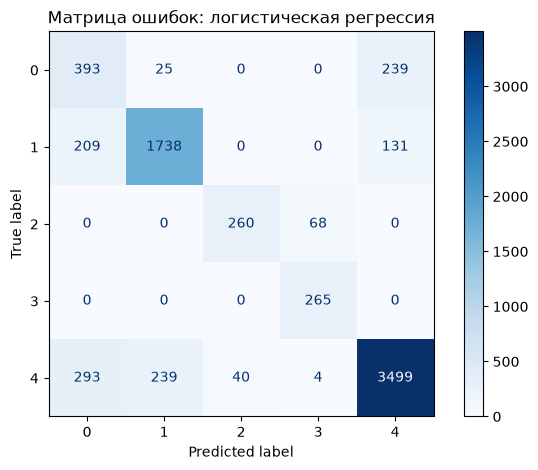

array([[ 393,   25,    0,    0,  239],
       [ 209, 1738,    0,    0,  131],
       [   0,    0,  260,   68,    0],
       [   0,    0,    0,  265,    0],
       [ 293,  239,   40,    4, 3499]])

In [38]:
logreg_cm = confusion_matrix(y_test_logreg, logreg_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=logreg_cm,
    display_labels=sorted(y_test_logreg.unique())
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Матрица ошибок: логистическая регрессия")
plt.tight_layout()
plt.show()

logreg_cm

#### 5. Отбор важных признаков для логистической регрессии

In [39]:
import numpy as np

# У One-vs-Rest внутри несколько моделей, по одной на каждый класс
# Взял модули коэффициентов и усреднил по классам
logreg_weights = np.array([
    estimator.coef_[0]
    for estimator in logreg_model.estimators_
])

feature_importance = np.mean(np.abs(logreg_weights), axis=0)

logreg_importance_df = pd.DataFrame({
    "feature": X_train_logreg.columns,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

logreg_importance_df.head(10)

,feature,importance
9,y_var,3.670680
10,y_max,3.077939
11,y_min,2.394822
1,x_var,2.314957
8,y_mean,2.222651
16,z_mean,1.960000
17,z_var,1.826585
19,z_min,1.713238
22,z_spectral_energy,1.683511
14,y_spectral_energy,1.608125


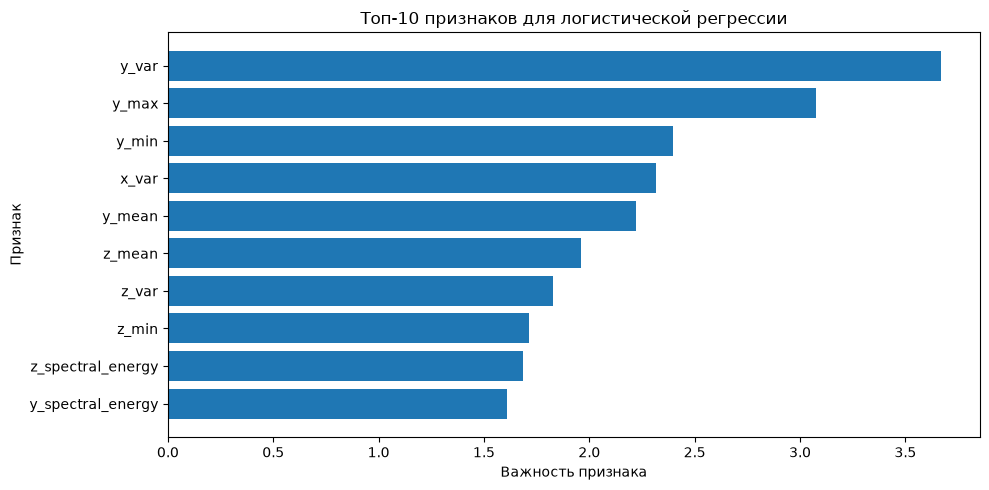

In [40]:
top_n = 10
top_logreg_features = logreg_importance_df.head(top_n)

plt.figure(figsize=(10, 5))

plt.barh(
    top_logreg_features["feature"][::-1],
    top_logreg_features["importance"][::-1]
)

plt.title("Топ-10 признаков для логистической регрессии")
plt.xlabel("Важность признака")
plt.ylabel("Признак")

plt.tight_layout()
plt.show()

#### 6. Проверка логистической регрессии на выбранных признаках

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

selected_logreg_features = top_logreg_features["feature"].tolist()

X_train_logreg_selected = X_train_logreg[selected_logreg_features]
X_test_logreg_selected = X_test_logreg[selected_logreg_features]

selected_logreg_scaler = StandardScaler()

X_train_logreg_selected_scaled = selected_logreg_scaler.fit_transform(X_train_logreg_selected)
X_test_logreg_selected_scaled = selected_logreg_scaler.transform(X_test_logreg_selected)

selected_logreg_model = OneVsRestClassifier(
    LogisticRegression(
        solver="lbfgs",
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    )
)

selected_logreg_model.fit(X_train_logreg_selected_scaled, y_train_logreg)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](5,)","[0,1,2,3,4]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,10
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'


In [42]:
start_time = time.perf_counter()

selected_logreg_pred = selected_logreg_model.predict(X_test_logreg_selected_scaled)

selected_total_time_ms = (time.perf_counter() - start_time) * 1000
selected_avg_time_ms = selected_total_time_ms / len(y_test_logreg)

selected_logreg_accuracy = accuracy_score(y_test_logreg, selected_logreg_pred)
selected_logreg_f1_macro = f1_score(y_test_logreg, selected_logreg_pred, average="macro")
selected_logreg_f1_micro = f1_score(y_test_logreg, selected_logreg_pred, average="micro")

print("Accuracy:", selected_logreg_accuracy)
print("F1-score macro:", selected_logreg_f1_macro)
print("F1-score micro:", selected_logreg_f1_micro)
print("Среднее время предсказания одного объекта, мс:", selected_avg_time_ms)

print()
print(classification_report(y_test_logreg, selected_logreg_pred, zero_division=0))

Accuracy: 0.7652303120356612
F1-score macro: 0.7332175110485746
F1-score micro: 0.7652303120356612
Среднее время предсказания одного объекта, мс: 0.000245657118066781

              precision    recall  f1-score   support

           0       0.30      0.51      0.38       657
           1       0.83      0.75      0.79      2078
           2       0.79      0.79      0.79       328
           3       0.78      1.00      0.88       265
           4       0.86      0.80      0.83      4075

    accuracy                           0.77      7403
   macro avg       0.71      0.77      0.73      7403
weighted avg       0.80      0.77      0.78      7403



##### Вывод
После отбора 10 наиболее важных признаков качество логистической регрессии снизилось примерно на 5%.
Это значит, что оставшиеся признаки действительно содержат большую часть полезной информации, но полный набор из 24 признаков всё же дает более точный результат.

#### 7. Сравнение логистической регрессии на полном и сокращенном наборе признаков

In [43]:
logreg_comparison = pd.DataFrame({
    "Вариант": [
        "Все 24 признака",
        "Топ-10 признаков"
    ],
    "Accuracy": [
        logreg_accuracy,
        selected_logreg_accuracy
    ],
    "F1-score macro": [
        logreg_f1_macro,
        selected_logreg_f1_macro
    ],
    "F1-score micro": [
        logreg_f1_micro,
        selected_logreg_f1_micro
    ],
    "Время на 1 объект, мс": [
        logreg_avg_time_ms,
        selected_avg_time_ms
    ]
})

logreg_comparison

,Вариант,Accuracy,F1-score macro,F1-score micro,"Время на 1 объект, мс"
0,Все 24 признака,0.83142,0.789549,0.83142,0.001857
1,Топ-10 признаков,0.76523,0.733218,0.76523,0.000246


#### 8. Валидация MLP модели

In [44]:
start_time = time.perf_counter()

mlp_pred = mlp_model.predict(X_test_mlp_scaled)

total_time_ms = (time.perf_counter() - start_time) * 1000
mlp_avg_time_ms = total_time_ms / len(y_test_mlp)

mlp_accuracy = accuracy_score(y_test_mlp, mlp_pred)
mlp_f1_macro = f1_score(y_test_mlp, mlp_pred, average="macro")
mlp_f1_micro = f1_score(y_test_mlp, mlp_pred, average="micro")

print("Accuracy:", mlp_accuracy)
print("F1-score macro:", mlp_f1_macro)
print("F1-score micro:", mlp_f1_micro)
print("Среднее время предсказания одного объекта, мс:", mlp_avg_time_ms)

print()
print(classification_report(y_test_mlp, mlp_pred, zero_division=0))

Accuracy: 0.8469539375928677
F1-score macro: 0.8179197629363057
F1-score micro: 0.8469539375928677
Среднее время предсказания одного объекта, мс: 0.0021777927948987983

              precision    recall  f1-score   support

           0       0.54      0.65      0.59       657
           1       0.88      0.85      0.86      2078
           2       0.99      0.79      0.88       328
           3       0.78      1.00      0.88       265
           4       0.89      0.87      0.88      4075

    accuracy                           0.85      7403
   macro avg       0.81      0.83      0.82      7403
weighted avg       0.86      0.85      0.85      7403



#### 9. Матрица ошибок для MLP модели

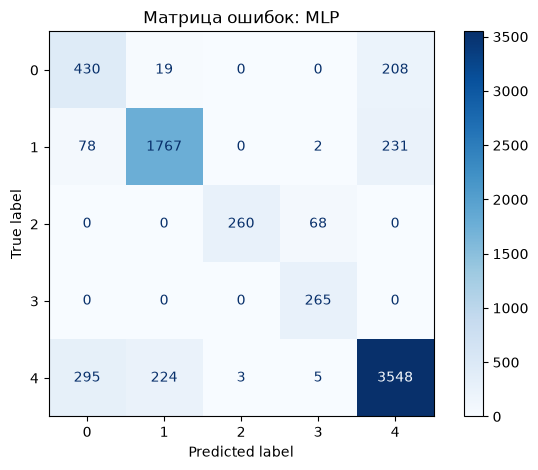

array([[ 430,   19,    0,    0,  208],
       [  78, 1767,    0,    2,  231],
       [   0,    0,  260,   68,    0],
       [   0,    0,    0,  265,    0],
       [ 295,  224,    3,    5, 3548]])

In [45]:
mlp_cm = confusion_matrix(y_test_mlp, mlp_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=mlp_cm,
    display_labels=sorted(y_test_mlp.unique())
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Матрица ошибок: MLP")
plt.tight_layout()
plt.show()

mlp_cm

#### 10. Отбор признаков для MLP модели

In [46]:
from sklearn.feature_selection import SelectKBest, f_classif

top_k = 10

selector = SelectKBest(score_func=f_classif, k=top_k)

X_train_mlp_selected = selector.fit_transform(X_train_mlp, y_train_mlp)
X_test_mlp_selected = selector.transform(X_test_mlp)

selected_mlp_features = X_train_mlp.columns[selector.get_support()].tolist()

selected_mlp_features

['x_var',
 'y_var',
 'y_max',
 'y_min',
 'y_zcr',
 'z_mean',
 'z_min',
 'z_energy',
 'z_zcr',
 'z_spectral_energy']

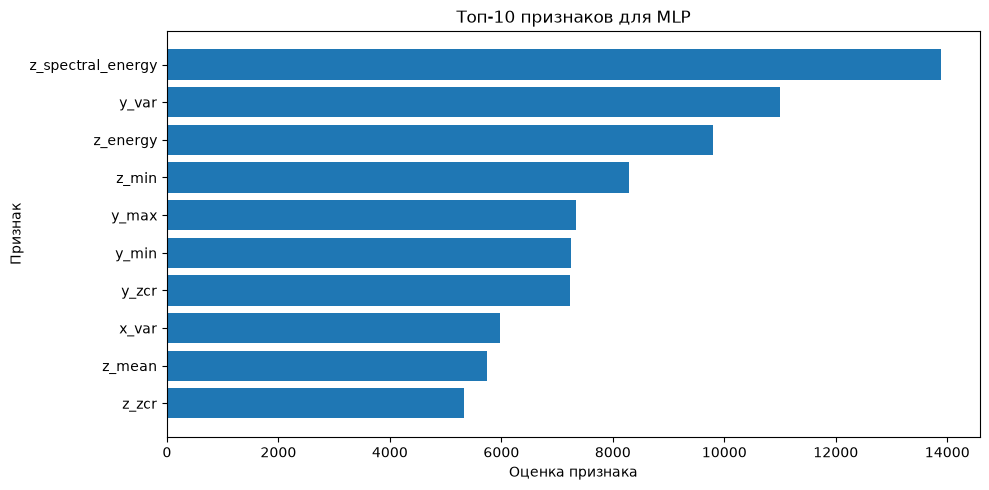

,feature,score
22,z_spectral_energy,13892.306243
9,y_var,11002.487334
20,z_energy,9798.131429
19,z_min,8284.885548
10,y_max,7340.379382
11,y_min,7256.249868
13,y_zcr,7232.886972
1,x_var,5977.891218
16,z_mean,5745.633930
21,z_zcr,5337.591439


In [53]:
mlp_feature_scores = pd.DataFrame({
    "feature": X_train_mlp.columns,
    "score": selector.scores_
}).sort_values("score", ascending=False)

plt.figure(figsize=(10, 5))

top_scores = mlp_feature_scores.head(top_k)

plt.barh(
    top_scores["feature"][::-1],
    top_scores["score"][::-1]
)

plt.title("Топ-10 признаков для MLP")
plt.xlabel("Оценка признака")
plt.ylabel("Признак")

plt.tight_layout()
plt.show()

top_scores

#### 11. Проверка MLP на выбранных признаках

In [48]:
from sklearn.neural_network import MLPClassifier

selected_mlp_scaler = StandardScaler()

X_train_mlp_selected_scaled = selected_mlp_scaler.fit_transform(X_train_mlp_selected)
X_test_mlp_selected_scaled = selected_mlp_scaler.transform(X_test_mlp_selected)

selected_mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    early_stopping=True,
    random_state=42,
    alpha=0.0001,
    max_iter=200,
    validation_fraction=0.15,
    n_iter_no_change=10,
    batch_size=200
)

selected_mlp_model.fit(X_train_mlp_selected_scaled, y_train_mlp)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",200
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.15
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse s

In [49]:
start_time = time.perf_counter()

selected_mlp_pred = selected_mlp_model.predict(X_test_mlp_selected_scaled)

selected_mlp_total_time_ms = (time.perf_counter() - start_time) * 1000
selected_mlp_avg_time_ms = selected_mlp_total_time_ms / len(y_test_mlp)

selected_mlp_accuracy = accuracy_score(y_test_mlp, selected_mlp_pred)
selected_mlp_f1_macro = f1_score(y_test_mlp, selected_mlp_pred, average="macro")
selected_mlp_f1_micro = f1_score(y_test_mlp, selected_mlp_pred, average="micro")

print("Accuracy:", selected_mlp_accuracy)
print("F1-score macro:", selected_mlp_f1_macro)
print("F1-score micro:", selected_mlp_f1_micro)
print("Среднее время предсказания одного объекта, мс:", selected_mlp_avg_time_ms)

print()
print(classification_report(y_test_mlp, selected_mlp_pred, zero_division=0))

Accuracy: 0.8549236795893557
F1-score macro: 0.7903239406341722
F1-score micro: 0.8549236795893557
Среднее время предсказания одного объекта, мс: 0.0010250033978053271

              precision    recall  f1-score   support

           0       0.64      0.40      0.49       657
           1       0.88      0.87      0.87      2078
           2       0.84      0.79      0.81       328
           3       0.78      1.00      0.88       265
           4       0.87      0.92      0.89      4075

    accuracy                           0.85      7403
   macro avg       0.80      0.80      0.79      7403
weighted avg       0.85      0.85      0.85      7403



#### 12. Сравнение MLP на полном и сокращенном наборе признаков

In [50]:
mlp_comparison = pd.DataFrame({
    "Вариант": [
        "24 признака",
        "Топ-10 признаков"
    ],
    "Accuracy": [
        mlp_accuracy,
        selected_mlp_accuracy
    ],
    "F1-score macro": [
        mlp_f1_macro,
        selected_mlp_f1_macro
    ],
    "F1-score micro": [
        mlp_f1_micro,
        selected_mlp_f1_micro
    ],
    "Время на 1 объект, мс": [
        mlp_avg_time_ms,
        selected_mlp_avg_time_ms
    ]
})

mlp_comparison

,Вариант,Accuracy,F1-score macro,F1-score micro,"Время на 1 объект, мс"
0,24 признака,0.846954,0.817920,0.846954,0.002178
1,Топ-10 признаков,0.854924,0.790324,0.854924,0.001025


##### Вывод

После отбора 10 признаков accuracy MLP немного выросла: с `0.8469` до `0.8549`.
Однако `F1-score macro` снизился: с `0.8179` до `0.7903`. Это значит, что общая доля правильных ответов стала немного выше, но качество по отдельным классам стало менее равномерным.
Также сильно уменьшилось среднее время предсказания одного объекта: с `0.00217` мс до `0.001` мс. Это связано с тем, что модель получает меньше признаков на вход.

#### 13. Итоговые результаты эксперимента

In [51]:
final_results = pd.DataFrame({
    "Модель": [
        "LR, 24 признака",
        "LR, топ-10 признаков",
        "MLP, 24 признака",
        "MLP, топ-10 признаков"
    ],
    "Accuracy": [
        logreg_accuracy,
        selected_logreg_accuracy,
        mlp_accuracy,
        selected_mlp_accuracy
    ],
    "F1-score macro": [
        logreg_f1_macro,
        selected_logreg_f1_macro,
        mlp_f1_macro,
        selected_mlp_f1_macro
    ],
    "F1-score micro": [
        logreg_f1_micro,
        selected_logreg_f1_micro,
        mlp_f1_micro,
        selected_mlp_f1_micro
    ],
    "Время на 1 объект, мс": [
        logreg_avg_time_ms,
        selected_avg_time_ms,
        mlp_avg_time_ms,
        selected_mlp_avg_time_ms
    ]
})

final_results


,Модель,Accuracy,F1-score macro,F1-score micro,"Время на 1 объект, мс"
0,"LR, 24 признака",0.831420,0.789549,0.831420,0.001857
1,"LR, топ-10 признаков",0.765230,0.733218,0.765230,0.000246
2,"MLP, 24 признака",0.846954,0.817920,0.846954,0.002178
3,"MLP, топ-10 признаков",0.854924,0.790324,0.854924,0.001025


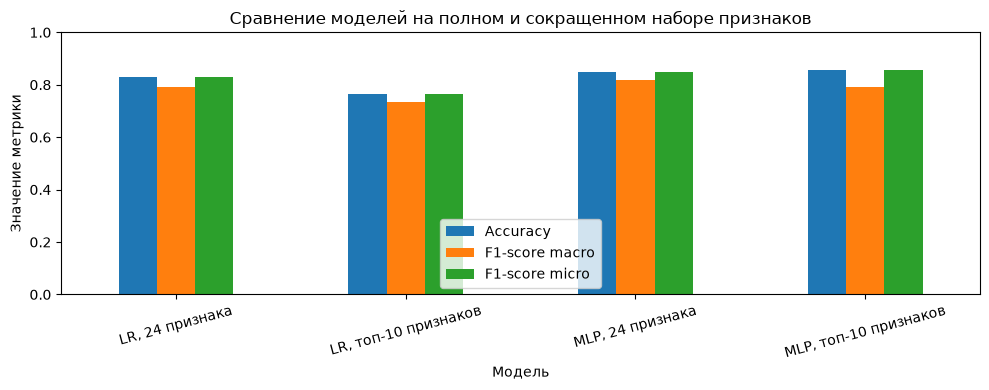

In [52]:
final_results.set_index("Модель")[["Accuracy", "F1-score macro", "F1-score micro"]].plot(
    kind="bar",
    figsize=(10, 4)
)

plt.title("Сравнение моделей на полном и сокращенном наборе признаков")
plt.ylabel("Значение метрики")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()
